In [13]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [14]:
from boulder_statistics.analysis.log_normal_fitting import LogNormalFitting
from boulder_statistics.analysis.sensitivity_model.KDE_bootstrapped_sensitivity_model import KDEBootstrappedSensitivityModel

sm = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg)
fit = LogNormalFitting(dp, LAD_min=0, sensitivity_model = sm, min_alpha_to_consider = int(1e3))

In [15]:
from statsmodels.base.model import GenericLikelihoodModelResults
from boulder_statistics.analysis.fit_params.log_normal_fit_params import LogNormalFitParams

mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
    optimize_params = LogNormalFitParams(mu=-2.302585093, sigma=2),
    verbose = False,
)

                              TheoryFit Results                               
Dep. Variable:                      y   Log-Likelihood:            -1.8646e+05
Model:                      TheoryFit   AIC:                         3.729e+05
Method:            Maximum Likelihood   BIC:                         3.730e+05
Date:                Mon, 06 Jul 2026                                         
Time:                        10:31:39                                         
No. Observations:               21963                                         
Df Residuals:                   21961                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0         -14.1241      2.987     -4.728      0.000     -19.980      -8.269
par1           3.5221      0.331     10.627      0.0

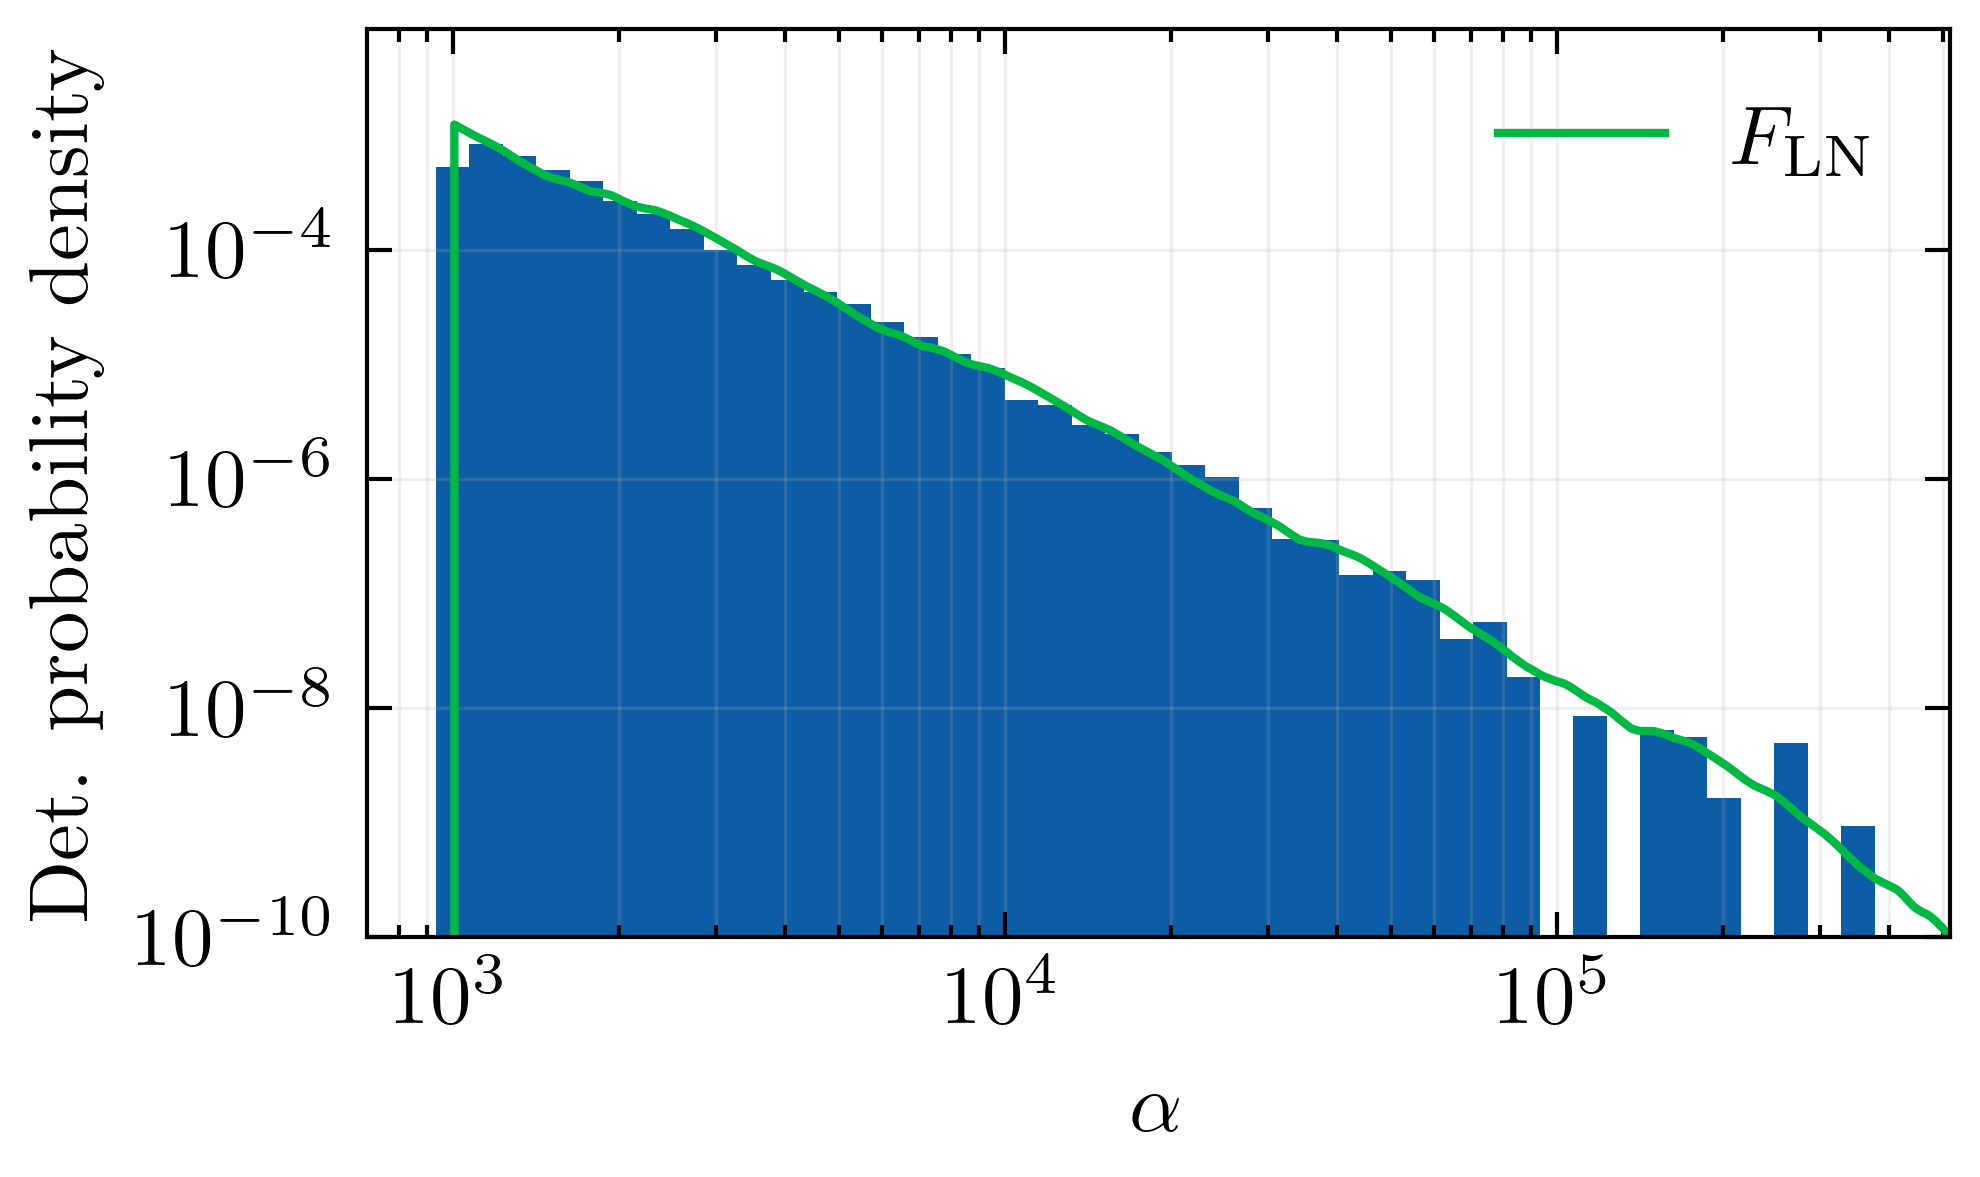

In [16]:
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_alphas_best_S,
                           alphas_hist, density = True)

fit_params = LogNormalFitParams(*mle_model.params)
# fit_params = LogNormalFitParams(mu=-5.302585093, sigma=2)
plt.plot(alphas, fit.F_norm(alphas, fit_params, sm.best_S_function), label = r"$F_{\text{LN}}$")

plt.ylim(1e-10, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * (1/0.7))
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.show()

In [17]:
from datetime import datetime

output_dir = Path("MLE_random_sample_fit_data/LogNormal")

while True:
    fit.min_alpha_to_consider = int(np.exp(np.random.uniform(
        np.log(1e2), np.log(1e4)
    )))
    
    df = fit.MultiMLEFit(
        optimize_params=fit_params,
        numb_runs=20,
        summary = False
    )

    # Filename based on current datetime (to the second)
    timestamp: str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename: Path = output_dir / f"{timestamp}.parquet"
    filename.parent.mkdir(parents=True, exist_ok=True)

    df.write_parquet(filename)

    print(f"Saved {filename}")

MultiMLE fit running: 100%|██████████| 20/20 [05:57<00:00, 17.85s/it]


Saved MLE_random_sample_fit_data\LogNormal\2026-07-06_10-37-37.parquet


MultiMLE fit running: 100%|██████████| 20/20 [02:48<00:00,  8.44s/it]


Saved MLE_random_sample_fit_data\LogNormal\2026-07-06_10-40-25.parquet


MultiMLE fit running: 100%|██████████| 20/20 [02:51<00:00,  8.57s/it]


...

Saved MLE_random_sample_fit_data\LogNormal\2026-07-06_11-18-06.parquet


MultiMLE fit running: 100%|██████████| 20/20 [03:06<00:00,  9.31s/it]


Saved MLE_random_sample_fit_data\LogNormal\2026-07-06_11-21-12.parquet


MultiMLE fit running:   0%|          | 0/20 [00:00<?, ?it/s]C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\PSFD_fitting_base.py:96: RuntimeWarning: divide by zero encountered in log
  np.log(total_p_alpha_sample),
C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\PSFD_fitting_base.py:145: RuntimeWarning: invalid value encountered in divide
  return self.F(alphas, fit_params, s_function) / int_F
C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\PSFD_fitting_base.py:171: RuntimeWarning: divide by zero encountered in log
  return np.log(F_norm(alphas, optimize_params, s_function))
MultiMLE fit running:  10%|█         | 2/20 [01:13<10:41, 35.66s/it]C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\PSFD_fitting_base.py:96: RuntimeWarning: divide by zero encountered in log
  np.log(total_p_alpha_sample),
C:\Users\Joshu\Document

KeyboardInterrupt: 